In [14]:
!pip install torch torchvision tqdm


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from tqdm import tqdm


In [17]:
BATCH_SIZE = 256

transform_test = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor()
])

train_data = datasets.STL10(root="./data", split="train", download=True, transform=transform_test)
test_data  = datasets.STL10(root="./data", split="test", download=True, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT = "/content/drive/MyDrive/simclr_checkpoints/simclr_epoch_200.pth"
state = torch.load(CHECKPOINT, map_location=device)

# extract only encoder keys
encoder_state = {}
for k, v in state["model"].items():
    if k.startswith("encoder."):
        encoder_state[k.replace("encoder.", "")] = v

# build encoder same as SimCLR
resnet = models.resnet18(weights=None)
encoder = nn.Sequential(*list(resnet.children())[:-1]).to(device)

encoder.load_state_dict(encoder_state, strict=False)
encoder.eval()
encoder.requires_grad_(False)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [19]:
num_classes = 10  # STL-10 labels

linear_head = nn.Linear(512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(linear_head.parameters(), lr=1e-3)


In [20]:
EPOCHS = 30

for epoch in range(1, EPOCHS+1):
    encoder.eval()
    linear_head.train()

    total, correct, total_loss = 0, 0, 0
    loop = tqdm(train_loader)

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            feats = encoder(imgs).squeeze()

        preds = linear_head(feats)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = preds.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_description(f"Epoch [{epoch}/{EPOCHS}]")
        loop.set_postfix(loss=total_loss/len(train_loader), acc=(100*correct/total))

    print(f"Epoch {epoch} | Train Acc: {100*correct/total:.2f}% | Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/30]: 100%|██████████| 20/20 [00:02<00:00,  8.44it/s, acc=44.2, loss=1.75]


Epoch 1 | Train Acc: 44.22% | Loss: 1.7465


Epoch [2/30]: 100%|██████████| 20/20 [00:02<00:00,  7.67it/s, acc=74.5, loss=0.904]


Epoch 2 | Train Acc: 74.52% | Loss: 0.9037


Epoch [3/30]: 100%|██████████| 20/20 [00:04<00:00,  4.94it/s, acc=76.8, loss=0.717]


...

Epoch 28 | Train Acc: 84.50% | Loss: 0.4374


Epoch [29/30]: 100%|██████████| 20/20 [00:02<00:00,  8.51it/s, acc=84.7, loss=0.433]


Epoch 29 | Train Acc: 84.66% | Loss: 0.4327


Epoch [30/30]: 100%|██████████| 20/20 [00:02<00:00,  8.56it/s, acc=84.8, loss=0.43]

Epoch 30 | Train Acc: 84.82% | Loss: 0.4299


In [21]:
encoder.eval()
linear_head.eval()
total, correct = 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        feats = encoder(imgs).squeeze()
        preds = linear_head(feats)
        _, predicted = preds.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print("\n🎉 FINAL TEST ACCURACY:", 100*correct/total, "%")



🎉 FINAL TEST ACCURACY: 80.425 %


In [22]:
# =======================
# 🔥 FINE-TUNE SIMCLR ENCODER (100% labeled STL-10)
# =======================

finetune_encoder = models.resnet18(weights=None)
finetune_encoder = nn.Sequential(*list(finetune_encoder.children())[:-1]).to(device)
finetune_encoder.load_state_dict(encoder_state, strict=False)  # load SimCLR backbone

# classifier head
finetune_head = nn.Linear(512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    list(finetune_encoder.parameters()) + list(finetune_head.parameters()),
    lr=1e-4
)

FINETUNE_EPOCHS = 20

print("\n🚀 Starting Fine-Tuning...")
for epoch in range(1, FINETUNE_EPOCHS+1):
    finetune_encoder.train()
    finetune_head.train()

    total, correct, loss_sum = 0, 0, 0
    loop = tqdm(train_loader)

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        feats = finetune_encoder(imgs).squeeze()
        preds = finetune_head(feats)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        _, pred = preds.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

        loop.set_description(f"FT Epoch [{epoch}/{FINETUNE_EPOCHS}]")
        loop.set_postfix(loss=loss_sum/len(train_loader), acc=100*correct/total)

    print(f"Epoch {epoch} | FineTune Acc: {100*correct/total:.2f}% | Loss: {loss_sum/len(train_loader):.4f}")

# evaluate fine-tuned encoder
finetune_encoder.eval()
finetune_head.eval()

total, correct = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        feats = finetune_encoder(imgs).squeeze()
        preds = finetune_head(feats)
        _, pred = preds.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

FT_ACC = 100 * correct / total
print("\n✨ FINE-TUNED MODEL TEST ACCURACY:", FT_ACC, "%")



🚀 Starting Fine-Tuning...


FT Epoch [1/20]: 100%|██████████| 20/20 [00:04<00:00,  4.50it/s, acc=23.2, loss=2.18]


Epoch 1 | FineTune Acc: 23.16% | Loss: 2.1766


FT Epoch [2/20]: 100%|██████████| 20/20 [00:03<00:00,  5.51it/s, acc=46.6, loss=1.9]


Epoch 2 | FineTune Acc: 46.56% | Loss: 1.8959


...

FT Epoch [19/20]: 100%|██████████| 20/20 [00:03<00:00,  5.52it/s, acc=89.4, loss=0.385]


Epoch 19 | FineTune Acc: 89.44% | Loss: 0.3849


FT Epoch [20/20]: 100%|██████████| 20/20 [00:03<00:00,  5.44it/s, acc=90.3, loss=0.36]

Epoch 20 | FineTune Acc: 90.26% | Loss: 0.3599



✨ FINE-TUNED MODEL TEST ACCURACY: 82.8375 %


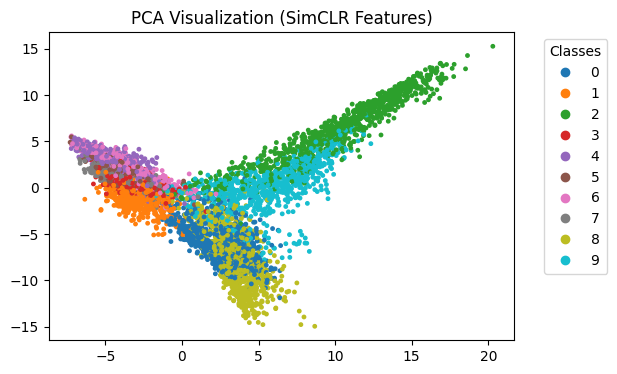

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


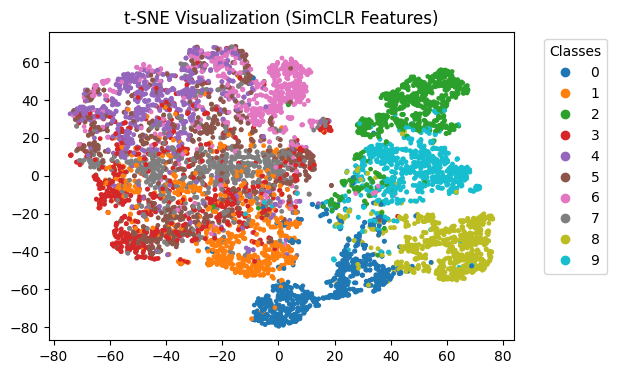

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

ENC = encoder  # use final encoder
ENC.eval()

all_feats, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in DataLoader(test_data, batch_size=256, shuffle=False):
        imgs = imgs.to(device)
        feats = ENC(imgs).squeeze().cpu().numpy()
        all_feats.append(feats)
        all_labels.append(lbls.numpy())

all_feats = np.concatenate(all_feats, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# PCA
pca = PCA(n_components=2)
pca_feats = pca.fit_transform(all_feats)

plt.figure(figsize=(6,4))
scatter = plt.scatter(pca_feats[:,0], pca_feats[:,1], c=all_labels, cmap='tab10', s=6)
plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05,1))
plt.title("PCA Visualization (SimCLR Features)")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
tsne_feats = tsne.fit_transform(all_feats)

plt.figure(figsize=(6,4))
scatter = plt.scatter(tsne_feats[:,0], tsne_feats[:,1], c=all_labels, cmap='tab10', s=6)
plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05,1))
plt.title("t-SNE Visualization (SimCLR Features)")
plt.show()
